In [23]:
import sys
from pathlib import Path

sys.path.insert(0, '../../')
import numpy as np
from matplotlib import pyplot as plt

import lsstypes as types
from clustering_statistics import tools, box_tools

plot_dir = Path('validation_c3_lightcone')
plot_dir.mkdir(exist_ok=True)
ext = 'pdf'

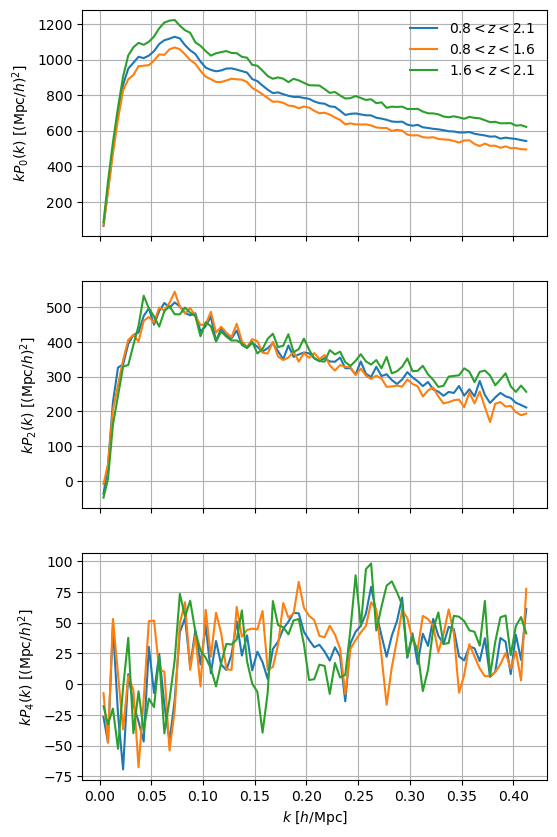

In [35]:
fig, lax = plt.subplots(3, figsize=(6, 10), sharex=True)

for zrange, color in zip([(0.8, 2.1), (0.8, 1.6), (1.6, 2.1)], ['C0', 'C1', 'C2']):
    fns = [tools.get_stats_fn(stats_dir=tools.base_stats_dir, tracer='QSO', project='full_shape/lightcone_validation', version='abacus-hf-lc-dr2-v1.9',
                       region='ALL', zrange=zrange, weight='default-FKP', imock=imock) for imock in range(25)]
    mean = types.mean([types.read(fn) for fn in fns]).select(k=slice(0, None, 5))
    for ill, ell in enumerate(mean.ells):
        ax = lax[ill]
        pole = mean.get(ell)
        ax.plot(k:=pole.coords('k'), k * pole.value(), color=color, label=f'${zrange[0]:.1f} < z < {zrange[1]:.1f}$')
        ax.grid(True)
        ax.set_ylabel(rf'$k P_{ell:d}(k)$ [$(\mathrm{{Mpc}}/h)^2$]')
    lax[0].legend(frameon=False)
ax.set_xlabel(r'$k$ [$h/\mathrm{Mpc}$]')
plt.show()

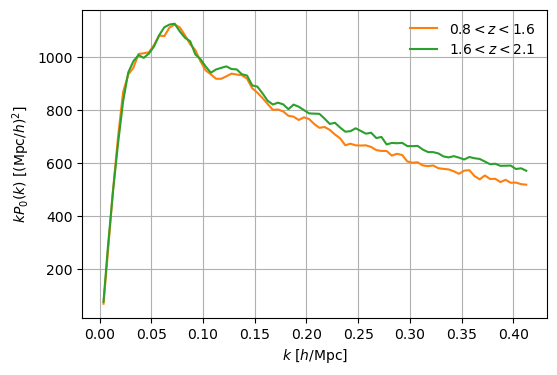

In [42]:
fig, lax = plt.subplots(1, figsize=(6, 4), sharex=True, squeeze=False)
lax = lax.ravel()
for zrange, color, scale in zip([(0.8, 1.6), (1.6, 2.1)], ['C1', 'C2'], [1.05, 0.92]):
    fns = [tools.get_stats_fn(stats_dir=tools.base_stats_dir, tracer='QSO', project='full_shape/lightcone_validation', version='abacus-hf-lc-dr2-v1.9',
                       region='ALL', zrange=zrange, weight='default-FKP', imock=imock) for imock in range(25)]
    mean = types.mean([types.read(fn) for fn in fns]).select(k=slice(0, None, 5))
    for ill, ell in enumerate(mean.ells[:1]):
        ax = lax[ill]
        pole = mean.get(ell)
        ax.plot(k:=pole.coords('k'), k * pole.value() * scale, color=color, label=f'${zrange[0]:.1f} < z < {zrange[1]:.1f}$')
        ax.grid(True)
        ax.set_ylabel(rf'$k P_{ell:d}(k)$ [$(\mathrm{{Mpc}}/h)^2$]')
    lax[0].legend(frameon=False)
ax.set_xlabel(r'$k$ [$h/\mathrm{Mpc}$]')
plt.show()